Time Series Forecasting — Power Demand

real 5-minute power-demand + weather dataset and build the project from raw data to forecasting.

The teaching flow is:

Raw data → Time features → Visualization → Baseline → Lag features → ML model → Evaluation → Future forecasting

The target is Power demand.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [6]:
df = pd.read_csv(
    "powerdemand_5min_2021_to_2024_with weather.csv"
)


df.head().style.background_gradient(cmap='Blues')


,Unnamed: 0,datetime,Power demand,temp,dwpt,rhum,wdir,wspd,pres,year,month,day,hour,minute,moving_avg_3
0,0,2021-01-01 00:30:00,2014.000000,8.000000,6.900000,93.000000,0.000000,0.000000,1017.000000,2021,1,1,0,30,nan
1,1,2021-01-01 00:35:00,2005.630000,8.000000,6.900000,93.000000,0.000000,0.000000,1017.000000,2021,1,1,0,35,nan
2,2,2021-01-01 00:40:00,1977.600000,8.000000,6.900000,93.000000,0.000000,0.000000,1017.000000,2021,1,1,0,40,1999.076667
3,3,2021-01-01 00:45:00,1976.440000,8.000000,6.900000,93.000000,0.000000,0.000000,1017.000000,2021,1,1,0,45,1986.556667
4,4,2021-01-01 00:50:00,1954.370000,8.000000,6.900000,93.000000,0.000000,0.000000,1017.000000,2021,1,1,0,50,1969.470000


Remove unnecessary index column

In [7]:
df = df.drop(columns=["Unnamed: 0"])

Convert datetime

In [8]:
# Convert datetime
df["datetime"] = pd.to_datetime(df["datetime"])

In [9]:
df = df.sort_values("datetime")

Remove duplicate timestamps

In [10]:
df = df.drop_duplicates(subset="datetime")

Set datetime as index

In [11]:
df = df.set_index("datetime")

In [12]:
print(df.head())

print(df.shape)

                     Power demand  temp  dwpt  rhum  wdir  wspd    pres  year  \
datetime                                                                        
2021-01-01 00:30:00       2014.00   8.0   6.9  93.0   0.0   0.0  1017.0  2021   
2021-01-01 00:35:00       2005.63   8.0   6.9  93.0   0.0   0.0  1017.0  2021   
2021-01-01 00:40:00       1977.60   8.0   6.9  93.0   0.0   0.0  1017.0  2021   
2021-01-01 00:45:00       1976.44   8.0   6.9  93.0   0.0   0.0  1017.0  2021   
2021-01-01 00:50:00       1954.37   8.0   6.9  93.0   0.0   0.0  1017.0  2021   

                     month  day  hour  minute  moving_avg_3  
datetime                                                     
2021-01-01 00:30:00      1    1     0      30           NaN  
2021-01-01 00:35:00      1    1     0      35           NaN  
2021-01-01 00:40:00      1    1     0      40   1999.076667  
2021-01-01 00:45:00      1    1     0      45   1986.556667  
2021-01-01 00:50:00      1    1     0      50   1969.470000 

Check missing values

In [13]:
print(df.isna().sum())

Power demand      0
temp              0
dwpt              0
rhum              0
wdir            540
wspd              0
pres              0
year              0
month             0
day               0
hour              0
minute            0
moving_avg_3      2
dtype: int64


Fill weather direction missing values:

In [14]:
df["wdir"] = df["wdir"].interpolate()

4. Understand the Time Series

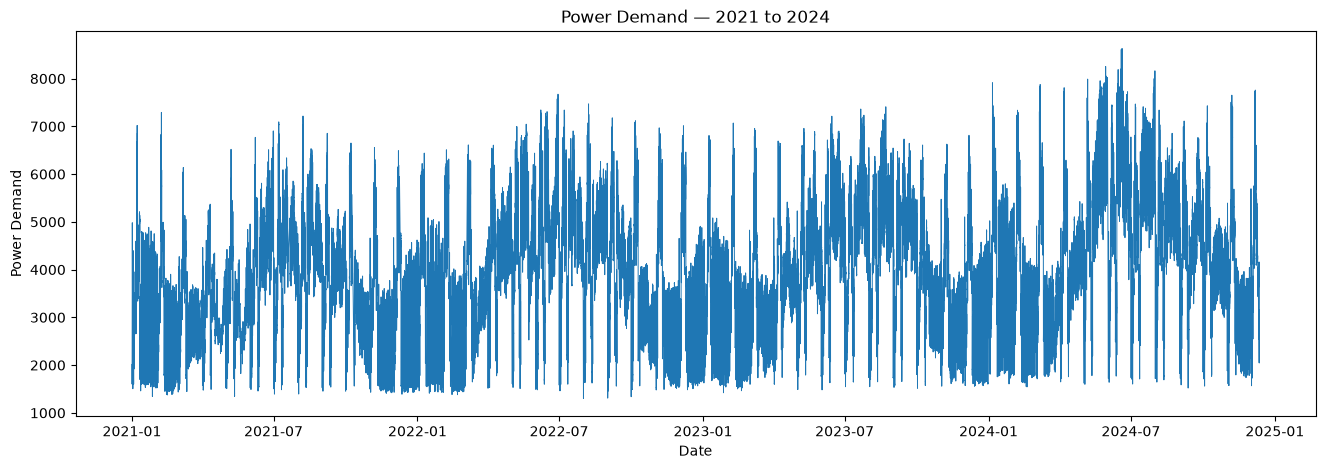

In [15]:
plt.figure(figsize=(16, 5))

plt.plot(
    df.index,
    df["Power demand"],
    linewidth=0.7
)

plt.title("Power Demand — 2021 to 2024")
plt.xlabel("Date")
plt.ylabel("Power Demand")

plt.show()

Instead of looking at four years at once, look at one week.

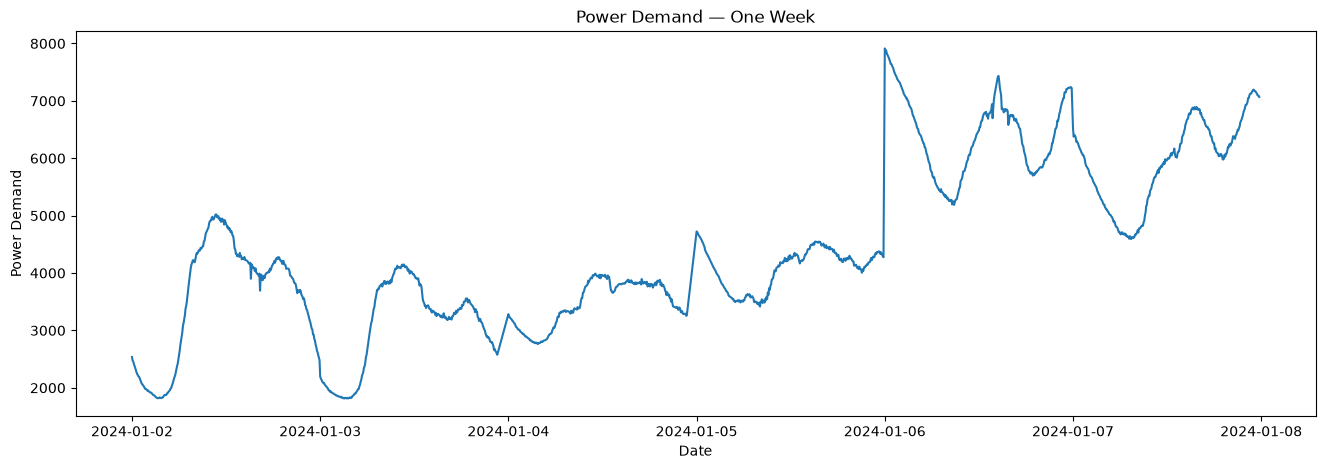

In [16]:
week = df.loc["2024-01-01":"2024-01-07"]

plt.figure(figsize=(16, 5))

plt.plot(
    week.index,
    week["Power demand"]
)

plt.title("Power Demand — One Week")
plt.xlabel("Date")
plt.ylabel("Power Demand")

plt.show()

You should start seeing repeating patterns.

Create Useful Time Features

In [17]:
df["year"] = df.index.year
df["month"] = df.index.month
df["day"] = df.index.day
df["dayofweek"] = df.index.dayofweek
df["hour"] = df.index.hour
df["minute"] = df.index.minute

Create a simple weekend feature:

In [18]:
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

Create a continuous time-of-day feature:

In [19]:
df["time_of_day"] = (
    df["hour"] * 60 + df["minute"]
)

Understand Daily Patterns

In [20]:
hourly_pattern = (
    df.groupby("hour")["Power demand"]
      .mean()
)

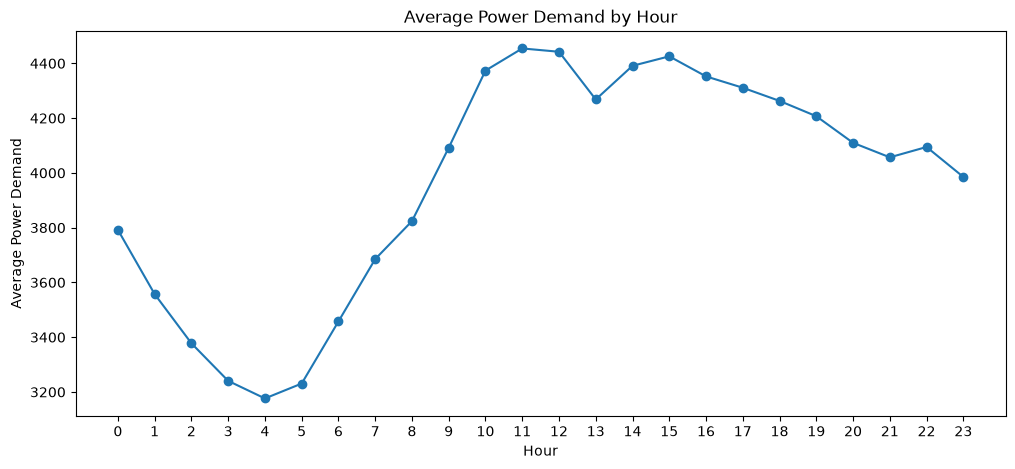

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_pattern.index,
    hourly_pattern.values,
    marker="o"
)

plt.title("Average Power Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Power Demand")
plt.xticks(range(24))

plt.show()

Weekend vs weekday:

In [22]:
weekday_pattern = (
    df.groupby("is_weekend")["Power demand"]
      .mean()
)

print(weekday_pattern)

is_weekend
0    4000.884197
1    3861.120072
Name: Power demand, dtype: float64


The Most Important Time-Series Concept: Lag

To predict the current demand, we can use previous demand.

For example:


Current demand
      ↑
Previous 5 minutes
Previous 10 minutes
Previous 15 minutes
Previous 1 hour
Previous 2 hours
Previous 1 day
Previous 1 week

Create them:

In [23]:
df["lag_1"] = df["Power demand"].shift(1)

df["lag_2"] = df["Power demand"].shift(2)

df["lag_3"] = df["Power demand"].shift(3)

df["lag_12"] = df["Power demand"].shift(12)

df["lag_24"] = df["Power demand"].shift(24)

df["lag_288"] = df["Power demand"].shift(288)

df["lag_2016"] = df["Power demand"].shift(2016)

Because the data is approximately 5-minute data:


12   → approximately 1 hour
288  → approximately 1 day
2016 → approximately 1 week

This is the key idea behind many practical time-series ML systems.

 Rolling Features

In [24]:
df["rolling_mean_1h"] = (
    df["Power demand"]
    .shift(1)
    .rolling(12)
    .mean()
)

df["rolling_mean_3h"] = (
    df["Power demand"]
    .shift(1)
    .rolling(36)
    .mean()
)

df["rolling_mean_1day"] = (
    df["Power demand"]
    .shift(1)
    .rolling(288)
    .mean()
)

In [25]:
df["rolling_std_1h"] = (
    df["Power demand"]
    .shift(1)
    .rolling(12)
    .std()
)

Remove Rows Created by Lagging

In [26]:
df = df.dropna()

print(df.shape)

(391424, 27)


 Train/Test Split

Never randomly shuffle a time series.

We train on the past and test on the future.

In [27]:
split_date = "2024-10-01"

train = df[df.index < split_date]

test = df[df.index >= split_date]

print("Train:", train.shape)
print("Test :", test.shape)

Train: (371663, 27)
Test : (19761, 27)


 Create X and y

In [28]:
features = [
    "temp",
    "dwpt",
    "rhum",
    "wdir",
    "wspd",
    "pres",

    "year",
    "month",
    "day",
    "dayofweek",
    "hour",
    "minute",
    "is_weekend",
    "time_of_day",

    "lag_1",
    "lag_2",
    "lag_3",
    "lag_12",
    "lag_24",
    "lag_288",
    "lag_2016",

    "rolling_mean_1h",
    "rolling_mean_3h",
    "rolling_mean_1day",
    "rolling_std_1h"
]

X_train = train[features]
y_train = train["Power demand"]

X_test = test[features]
y_test = test["Power demand"]


First Model — Random Forest

In [29]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

Predict:

In [30]:
predictions = model.predict(X_test)

Evaluate the Model

In [31]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 25.151095667678348
RMSE: 68.99352809764903


MAE is especially easy to understand:

MAE = average prediction error

MAE = 120

→ predictions are off by about 120 power-demand units on average.

Actual vs Predicted

In [32]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
}, index=y_test.index)

results.head()

,Actual,Predicted
datetime,,
2024-10-01 00:00:00,2645.32,5478.162009
2024-10-01 00:05:00,2576.55,2622.463949
2024-10-01 00:10:00,2524.91,2567.407250
2024-10-01 00:15:00,2481.90,2504.906560
2024-10-01 00:20:00,2444.37,2449.281776


Plot:

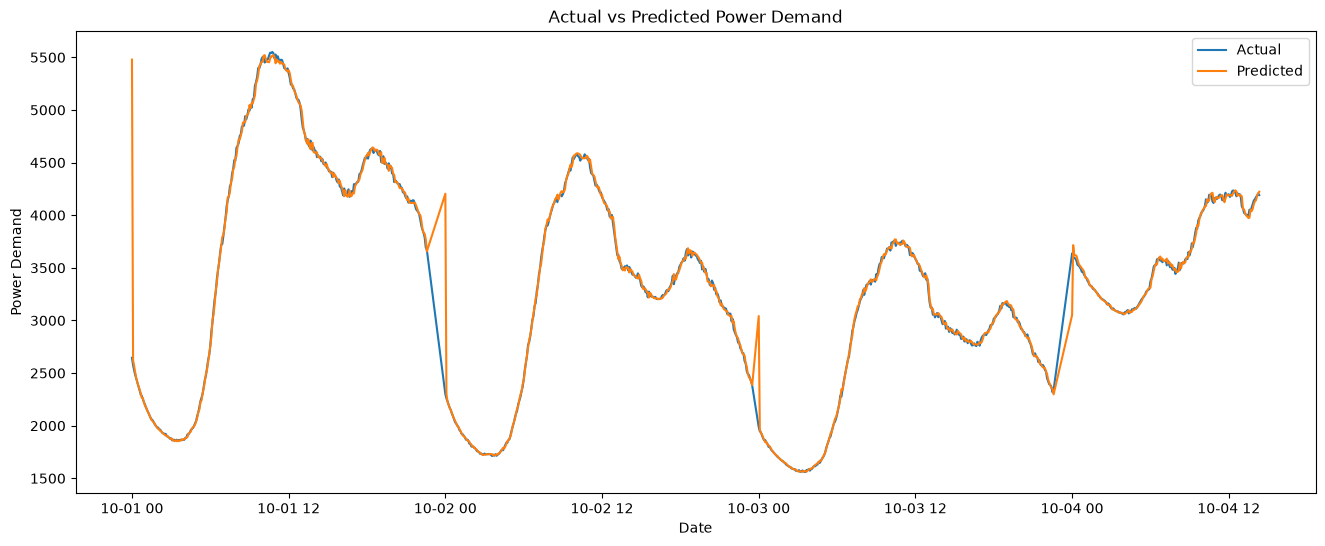

In [33]:
sample = results.iloc[:1000]

plt.figure(figsize=(16, 6))

plt.plot(
    sample.index,
    sample["Actual"],
    label="Actual"
)

plt.plot(
    sample.index,
    sample["Predicted"],
    label="Predicted"
)

plt.title("Actual vs Predicted Power Demand")

plt.xlabel("Date")
plt.ylabel("Power Demand")

plt.legend()

plt.show()

Compare Against a Simple Baseline

Before using ML, we should have a simple prediction.

For example:

> Tomorrow's demand ≈ today's demand at the same time.

In [34]:
baseline = test["lag_288"]

Evaluate:

In [35]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline
    )
)

print("Baseline MAE :", baseline_mae)
print("Model MAE    :", mae)

print()

print("Baseline RMSE:", baseline_rmse)
print("Model RMSE   :", rmse)

Baseline MAE : 585.8313551945752
Model MAE    : 25.151095667678348

Baseline RMSE: 807.0268034378392
Model RMSE   : 68.99352809764903


This is important.

A machine-learning model is useful only if it beats a sensible simple approach.

Feature Importance

Random Forest tells us which features helped the prediction.

In [36]:
importance = pd.Series(
    model.feature_importances_,
    index=features
)

importance = importance.sort_values(
    ascending=False
)

print(importance)


lag_1                0.997665
time_of_day          0.000517
day                  0.000285
temp                 0.000170
pres                 0.000149
lag_12               0.000125
lag_2016             0.000108
lag_2                0.000107
rolling_std_1h       0.000093
dwpt                 0.000089
lag_288              0.000083
lag_24               0.000079
rolling_mean_1h      0.000074
rolling_mean_3h      0.000065
rolling_mean_1day    0.000062
lag_3                0.000062
rhum                 0.000057
wdir                 0.000045
year                 0.000039
month                0.000036
wspd                 0.000031
minute               0.000023
dayofweek            0.000023
hour                 0.000011
is_weekend           0.000004
dtype: float64



Visualize:

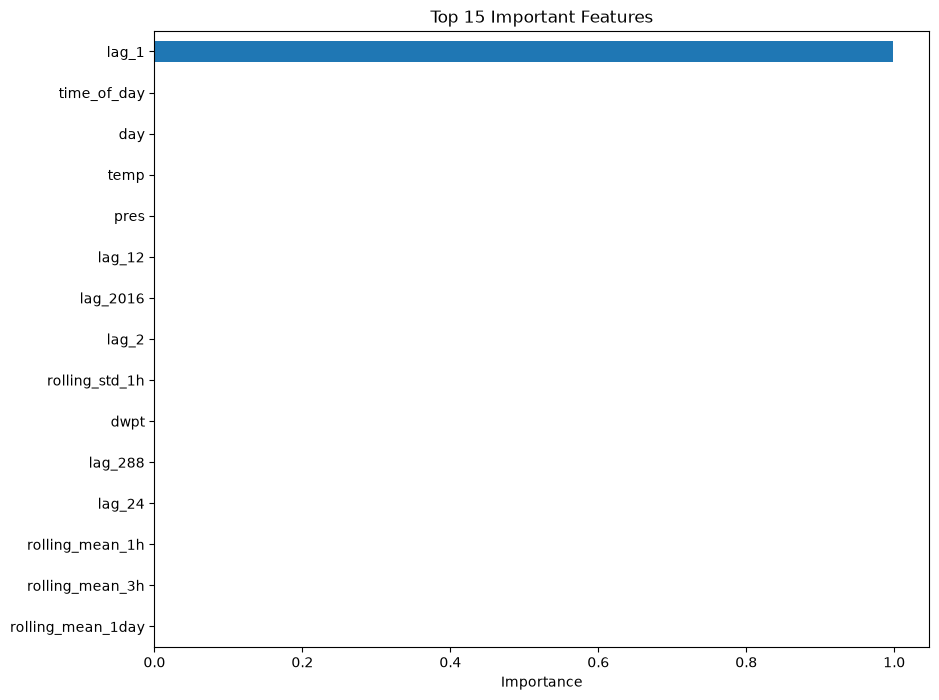

In [37]:

plt.figure(figsize=(10, 8))

importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.show()

You will likely see lag and time-related features becoming very important.

Test Different Forecast Horizons

Now we make the project more realistic.

Instead of predicting the current value, predict the next 1 hour.

Because the dataset is approximately 5-minute intervals:

1 hour ≈ 12 steps


Create the target:

In [38]:
df["target_1h"] = (
    df["Power demand"].shift(-12)
)

Remove the last rows:

In [39]:
forecast_df = df.dropna()

Build the 1-Hour-Ahead Model

In [40]:
train = forecast_df[
    forecast_df.index < split_date
]

test = forecast_df[
    forecast_df.index >= split_date
]

In [41]:
X_train = train[features]

y_train = train["target_1h"]

X_test = test[features]

y_test = test["target_1h"]

Train:

In [42]:
model_1h = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

model_1h.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

Predict:

In [43]:
pred_1h = model_1h.predict(X_test)

Evaluate:

In [44]:

mae_1h = mean_absolute_error(
    y_test,
    pred_1h
)

rmse_1h = np.sqrt(
    mean_squared_error(
        y_test,
        pred_1h
    )
)

print("1-Hour Forecast MAE :", mae_1h)
print("1-Hour Forecast RMSE:", rmse_1h)

1-Hour Forecast MAE : 105.25951876184767
1-Hour Forecast RMSE: 222.94879461579012


Visualize the Forecast

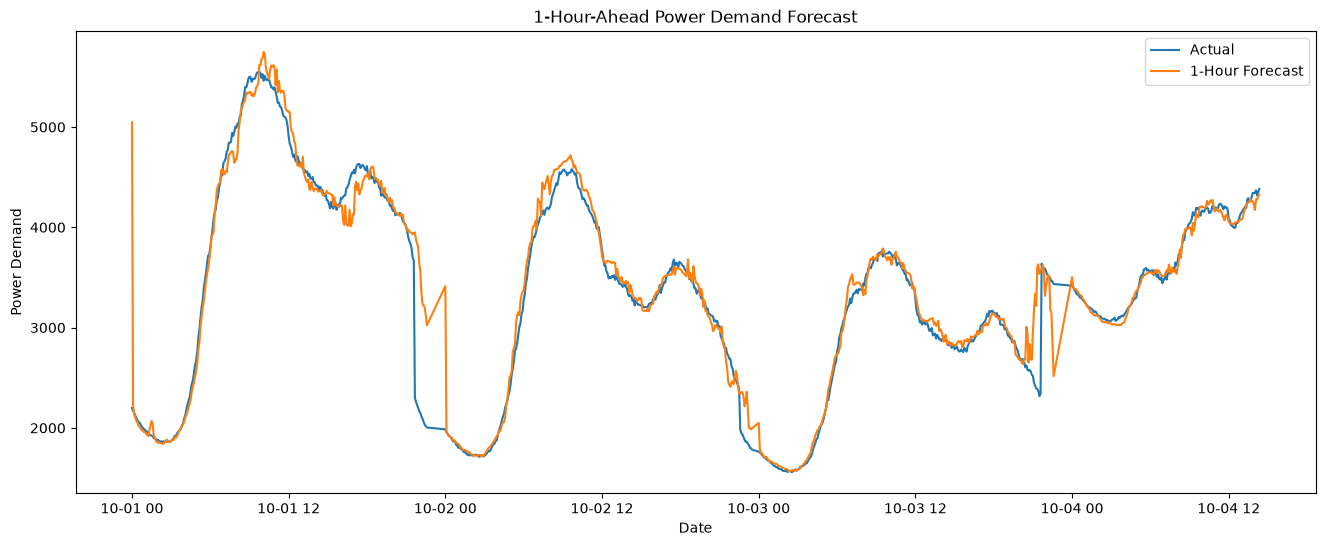

In [45]:
forecast_results = pd.DataFrame({
    "Actual": y_test.values,
    "Forecast": pred_1h
}, index=y_test.index)

sample = forecast_results.iloc[:1000]

plt.figure(figsize=(16, 6))

plt.plot(
    sample.index,
    sample["Actual"],
    label="Actual"
)

plt.plot(
    sample.index,
    sample["Forecast"],
    label="1-Hour Forecast"
)

plt.title(
    "1-Hour-Ahead Power Demand Forecast"
)

plt.xlabel("Date")
plt.ylabel("Power Demand")

plt.legend()

plt.show()

Forecast the Next Hour

Use the latest available observation:

In [46]:
latest = df.iloc[-1:]

X_latest = latest[features]

next_hour_prediction = model_1h.predict(
    X_latest
)

print(
    "Predicted power demand 1 hour ahead:",
    next_hour_prediction[0]
)

Predicted power demand 1 hour ahead: 1847.3851174233862


Complete  Forecast Function

In [47]:
def forecast_next_hour(model, df, features):

    latest = df.iloc[-1:]

    X_latest = latest[features]

    prediction = model.predict(X_latest)[0]

    return prediction


prediction = forecast_next_hour(
    model_1h,
    df,
    features
)

print(
    f"Next 1-hour power demand prediction: "
    f"{prediction:.2f}"
)

Next 1-hour power demand prediction: 1847.39


Save the Model

In [48]:
import joblib

joblib.dump(
    model_1h,
    "power_demand_forecaster.pkl"
)

joblib.dump(
    features,
    "power_demand_features.pkl"
)

['power_demand_features.pkl']


Load later:

In [49]:

model = joblib.load(
    "power_demand_forecaster.pkl"
)

features = joblib.load(
    "power_demand_features.pkl"
)

What students learn from this single project

```text
Time Series
    ↓
Datetime handling
    ↓
Time-based visualization
    ↓
Trend & seasonality
    ↓
Train/Test split without shuffling
    ↓
Lag features
    ↓
Rolling features
    ↓
Weather features
    ↓
Baseline forecasting
    ↓
Machine Learning forecasting
    ↓
MAE / RMSE
    ↓
Feature importance
    ↓
1-hour-ahead forecasting
    ↓
Saving the model
    ↓
Production-style prediction

